<a href="https://colab.research.google.com/github/rizki-ap/Gunshot-Locator/blob/main/FFT_2wav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
from scipy.io import wavfile
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
# Replace this with the direct URL to your .wav file on GitHub
wav_file_url_1 = 'https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/glock3_ch0.wav'
wav_file_url_2 = 'https://raw.githubusercontent.com/rizki-ap/Gunshot-Locator/main/sound/glock3_ch1.wav'
local_filename_1 = 'downloaded_audio_1.wav'
local_filename_2 = 'downloaded_audio_2.wav'

# Check if the URL is provided
if wav_file_url_1 == 'YOUR_GITHUB_RAW_WAV_FILE_URL_HERE':
    print("Please provide the direct URL to your WAV file from GitHub in the 'wav_file_url' variable.")
else:
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url_1}...")
        response = requests.get(wav_file_url_1)
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_filename_1, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_filename_1}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_filename_1}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Check if the URL is provided
if wav_file_url_2 == 'YOUR_GITHUB_RAW_WAV_FILE_URL_HERE':
    print("Please provide the direct URL to your WAV file from GitHub in the 'wav_file_url' variable.")
else:
    try:
        # Download the WAV file
        print(f"Downloading {wav_file_url_2}...")
        response = requests.get(wav_file_url_2)
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_filename_2, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded to {local_filename_2}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
    except FileNotFoundError:
        print(f"Error: The file '{local_filename_2}' was not found after download.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Downloaded to downloaded_audio_1.wav
Downloaded to downloaded_audio_2.wav


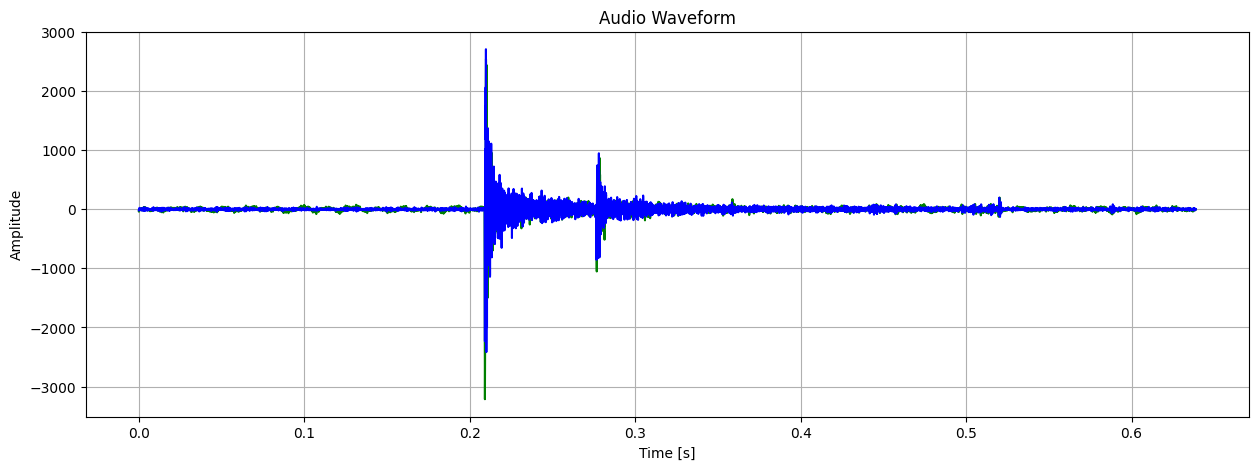

In [52]:
# Read the WAV file
samplerate1, data1 = wavfile.read(local_filename_1)
samplerate2, data2 = wavfile.read(local_filename_2)
if samplerate1 <= samplerate2 :
  samplerate = samplerate1
else :
  samplerate = samplerate2

# If stereo, take one channel for plotting
if data1.ndim > 1:
  data1 = data1[:, 0] # Take the first channel
if data2.ndim > 1:
  data2 = data2[:, 0] # Take the first channel

# Create a time array for the x-axis for the (possibly cropped) data
time1 = np.linspace(0., len(data1) / samplerate, len(data1))
time2 = np.linspace(0., len(data2) / samplerate, len(data2))

sine_50hz = np.sin(2 * np.pi * 50 * time1)
sine_120hz = 0.5 * np.sin(2 * np.pi * 120 * time1)
sine_320hz = 1.25 * np.sin(2 * np.pi * 320 * time1)
noise = 1.5 * np.random.normal(0, 0.5, len(sine_50hz))
mixed_sine = sine_50hz + sine_120hz + sine_320hz + noise


# Plot the waveform
plt.figure(figsize=(15, 5))
plt.plot(time1, data1,'g')
plt.plot(time2, data2,'b')
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.grid(True)
plt.show()


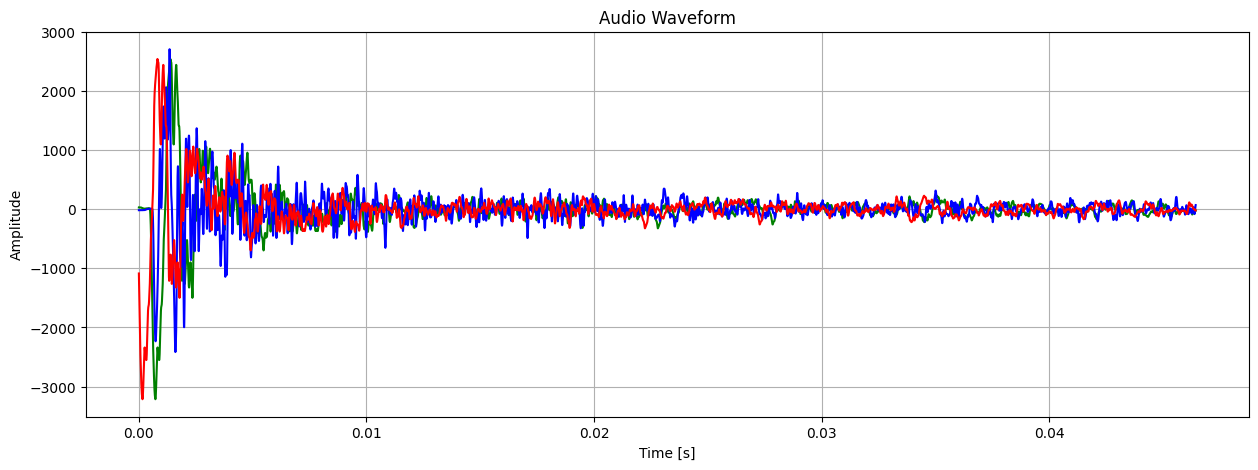

In [53]:
N_fft = 1024
delay_e = 100

# Find the index of the maximum amplitude in the cropped data
max_amplitude_index_1 = np.argmax(np.abs(data1))

# Get the maximum amplitude value
max_amplitude_value_1 = data1[max_amplitude_index_1]

# Create a cropped version of the audio data
cropped_start_index = int(max_amplitude_index_1 - (N_fft/8) )
cropped_end_index = int(cropped_start_index + N_fft * 8)
cropped_data1 = data1[cropped_start_index:cropped_end_index]
cropped_data2 = data2[cropped_start_index:cropped_end_index]
cropped_data3 = data1[cropped_start_index+delay_e:cropped_end_index+delay_e]
cropped_mixed_sine1 = mixed_sine[cropped_start_index:cropped_end_index]
cropped_mixed_sine2 = mixed_sine[cropped_start_index+delay_e:cropped_end_index+delay_e]

# Create a time array for the cropped data
cropped_time = np.linspace(0., len(cropped_data1) / samplerate, len(cropped_data1))

# Plot the waveform
plt.figure(figsize=(15, 5))
plt.plot(cropped_time, cropped_data1,'g')
plt.plot(cropped_time, cropped_data2,'b')
plt.plot(cropped_time, cropped_data3,'r')
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Audio Waveform")
plt.grid(True)
plt.show()

SciPy - Lag at maximum correlation: 1234 samples
SciPy - Time delay between signals: 0.006995 seconds


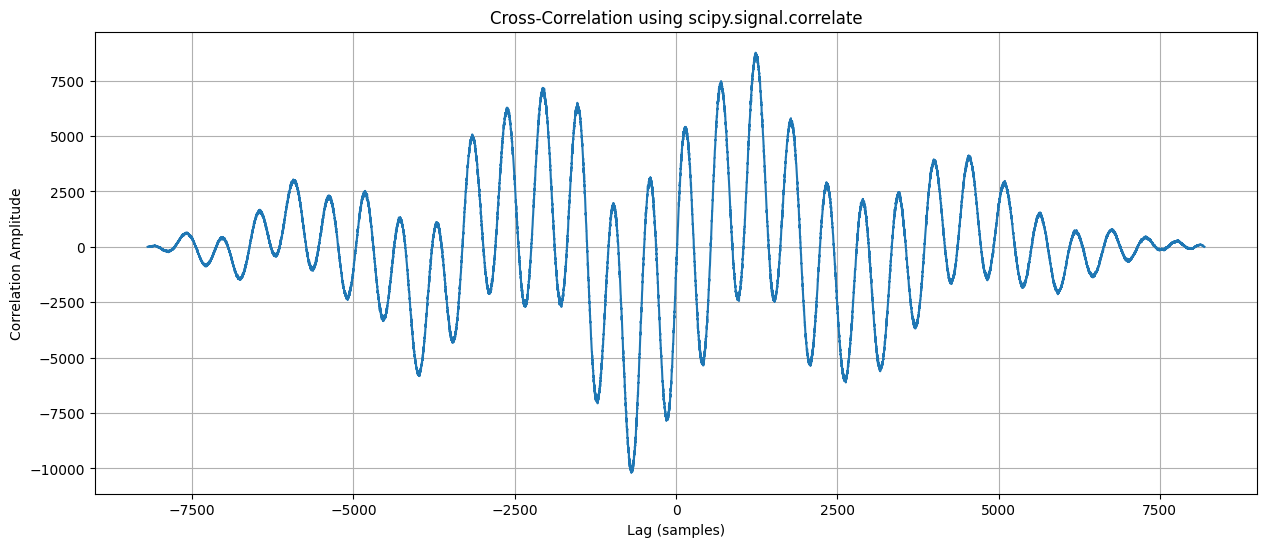

In [56]:
from scipy import signal

# Compute cross-correlation using scipy.signal.correlate
# 'full' mode is equivalent to numpy.correlate's 'full' mode
#scipy_correlation = np.correlate(cropped_data1, cropped_data1, mode='full')
#scipy_correlation = signal.correlate(data1, data2, mode='full')
#scipy_correlation = signal.correlate(cropped_mixed_sine1, cropped_mixed_sine2, mode='full')
#scipy_correlation = signal.fftconvolve(data1, data2, mode='full')
scipy_correlation = signal.fftconvolve(cropped_mixed_sine1, cropped_mixed_sine1, mode='full')

# The lags array will be the same as calculated for numpy.correlate
# since the output length for 'full' mode is 2*N - 1, where N is the length of the shorter signal (data1/data2 here)
#lags_scipy = np.arange(-len(data1) + 1, len(data1))
#lags_scipy = np.arange(-len(cropped_data1) + 1, len(cropped_data1))
lags_scipy = signal.correlation_lags(len(cropped_data1), len(cropped_data1), mode='full')

# You can also verify that the results are very similar (or identical depending on data types and implementation details)
# print("Are numpy and scipy correlation results close?", np.allclose(correlation, scipy_correlation))

# Find the index of the maximum correlation from SciPy's result
max_scipy_correlation_index = np.argmax(scipy_correlation)
lag_at_max_scipy_correlation = lags_scipy[max_scipy_correlation_index]
time_delay_scipy = lag_at_max_scipy_correlation / samplerate

print(f"SciPy - Lag at maximum correlation: {lag_at_max_scipy_correlation} samples")
print(f"SciPy - Time delay between signals: {time_delay_scipy:.6f} seconds")

# Plot the cross-correlation from SciPy
plt.figure(figsize=(15, 6))
plt.plot(lags_scipy, scipy_correlation)
plt.title('Cross-Correlation using scipy.signal.correlate')
plt.xlabel('Lag (samples)')
plt.ylabel('Correlation Amplitude')
plt.grid(True)
plt.show()